# 🤖 Notebook 03: Model Training and Evaluation

In this notebook, we split our data, train Naive Bayes and Logistic Regression classifiers, evaluate them across multiple classification metrics, and save the best performing model pipeline.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Add src to sys.path
sys.path.append(os.path.abspath('../src'))
from preprocess import clean_text
from evaluate import compute_metrics, plot_confusion_matrices, plot_precision_recall_comparison
from train import load_and_preprocess_data, train_and_evaluate, save_pipeline

## 1. Load Data

Let's load the cleaned and encoded dataset using our reusable `src/train.py` loader.

In [2]:
csv_path = os.path.join("..", "data", "spam.csv")
df = load_and_preprocess_data(csv_path)
display(df.head())

Loading dataset from: ..\data\spam.csv
Preprocessing raw text messages...


,label,message,clean_message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...,1
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though,0


## 2. Train and Evaluate Models

Let's run the model training, which: 
- Splits the dataset 80/20 with stratified labels.
- Fits the TF-IDF Vectorizer.
- Trains Naive Bayes (`MultinomialNB`) and `LogisticRegression` models.
- Computes key metrics and plots evaluations.

In [3]:
vectorizer, best_model, best_model_name, best_metrics, nb_metrics, lr_metrics, y_test, nb_pred, lr_pred = train_and_evaluate(df)

Training instances: 4457, Testing instances: 1115
Training Naive Bayes classifier (MultinomialNB)...
Training Logistic Regression classifier...

         EVALUATION METRICS TABLE
Metric          | Naive Bayes | Logistic Reg
----------------------------------------
Accuracy        | 0.9812      | 0.9812      
Precision       | 0.9848      | 0.9384      
Recall          | 0.8725      | 0.9195      
F1-Score        | 0.9253      | 0.9288      
Log Loss        | 0.0686      | 0.1495      
Saving evaluation visualizations to C:\Users\tapas\OneDrive\Desktop\.vscode\Minor-ML-project\plots...



Selected Model: Logistic Regression (F1-Score: 0.9288)


## 3. Visualize Performance Charts

Let's load and display the plots saved by the evaluator module.

Confusion Matrix:


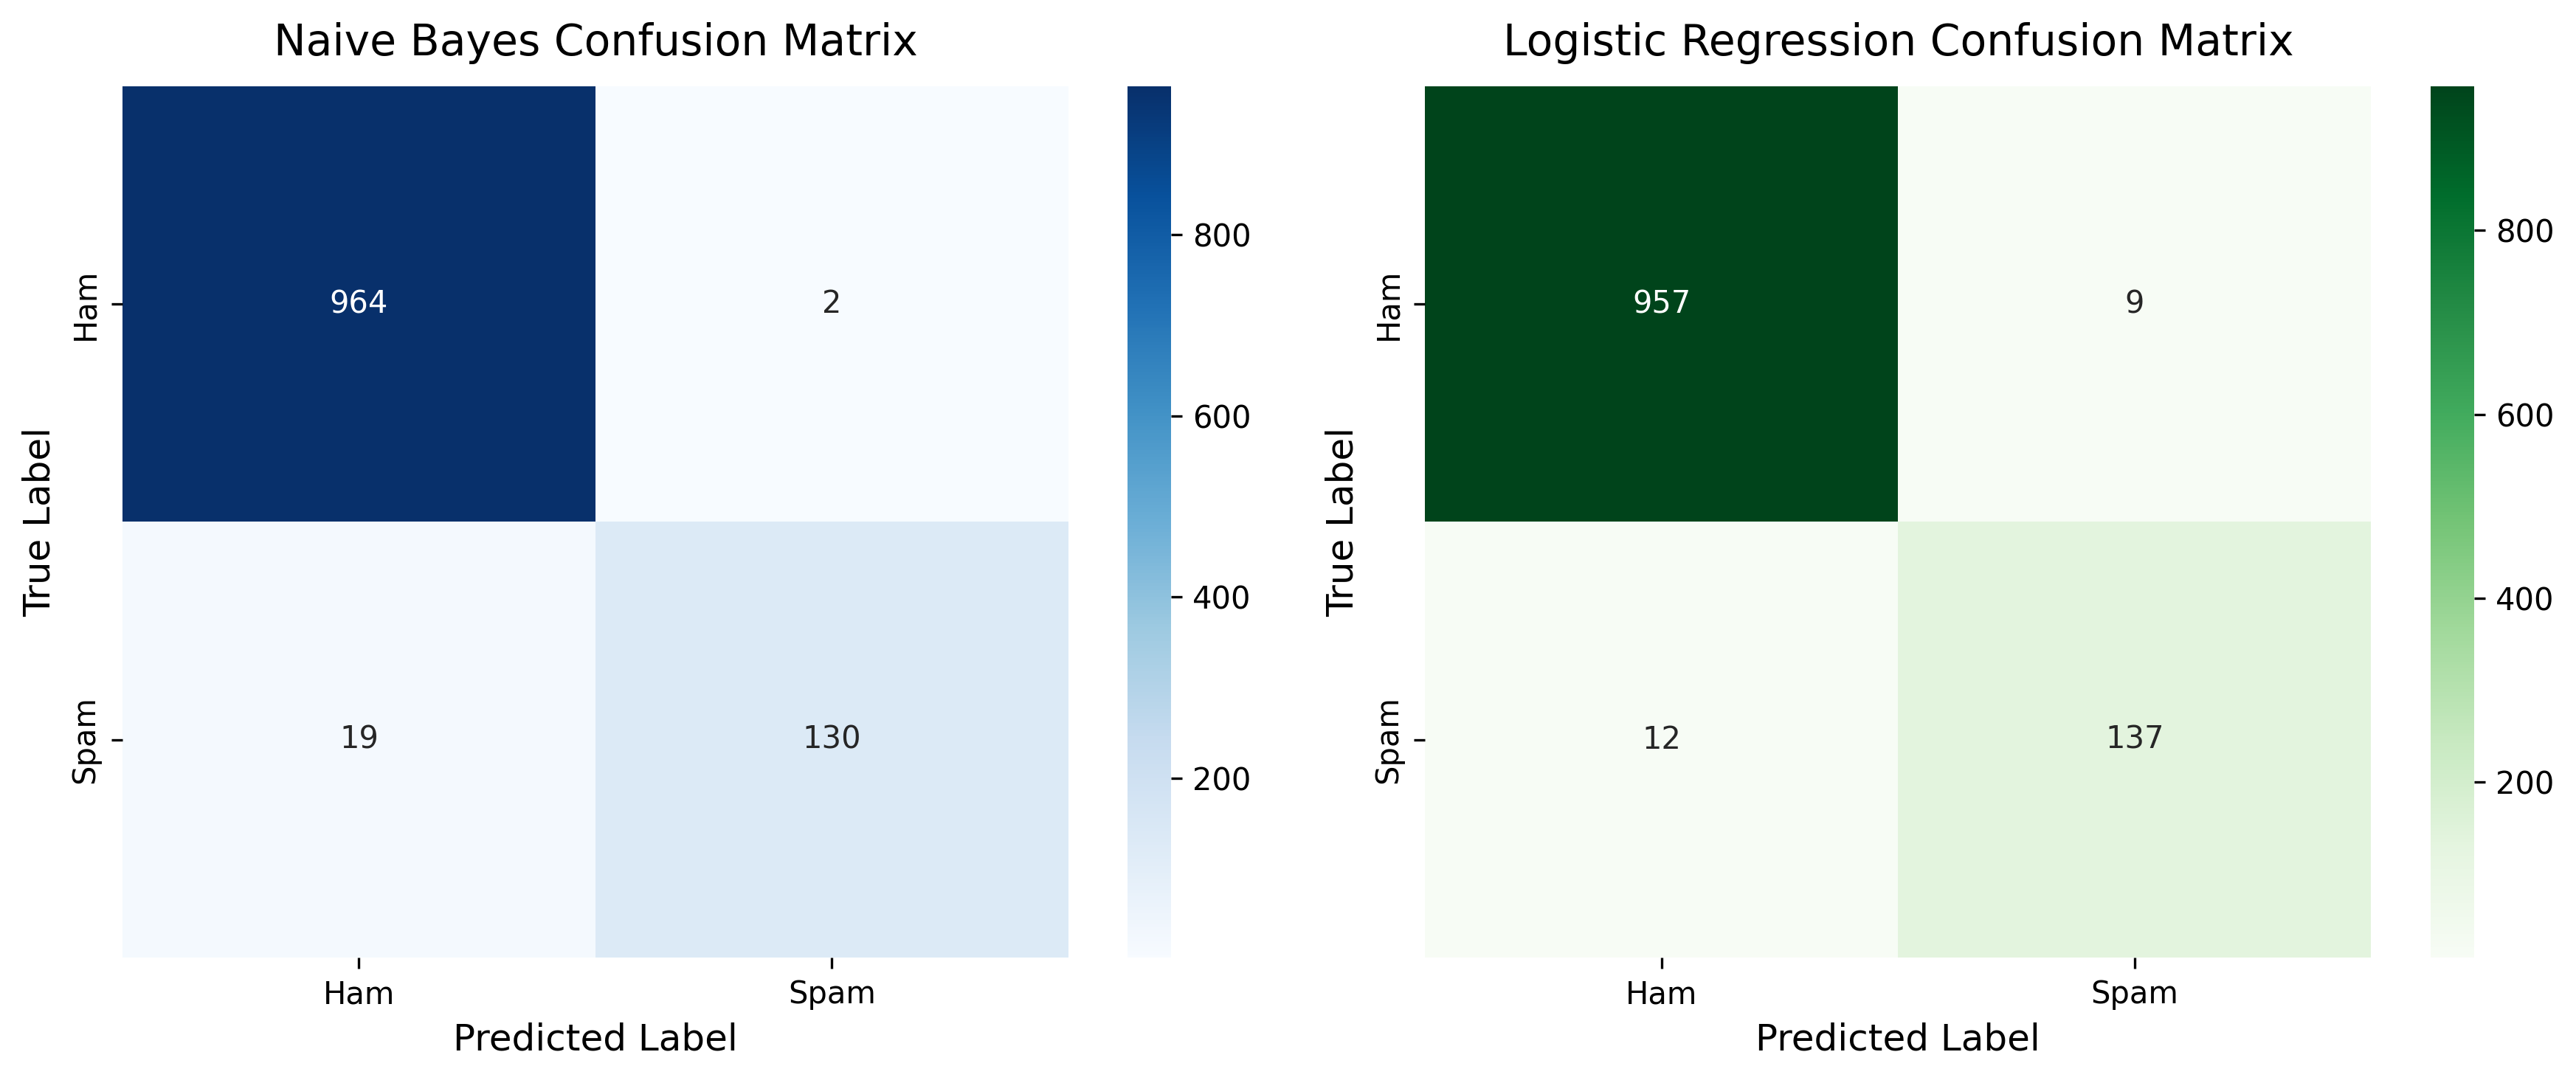


Performance Comparison:


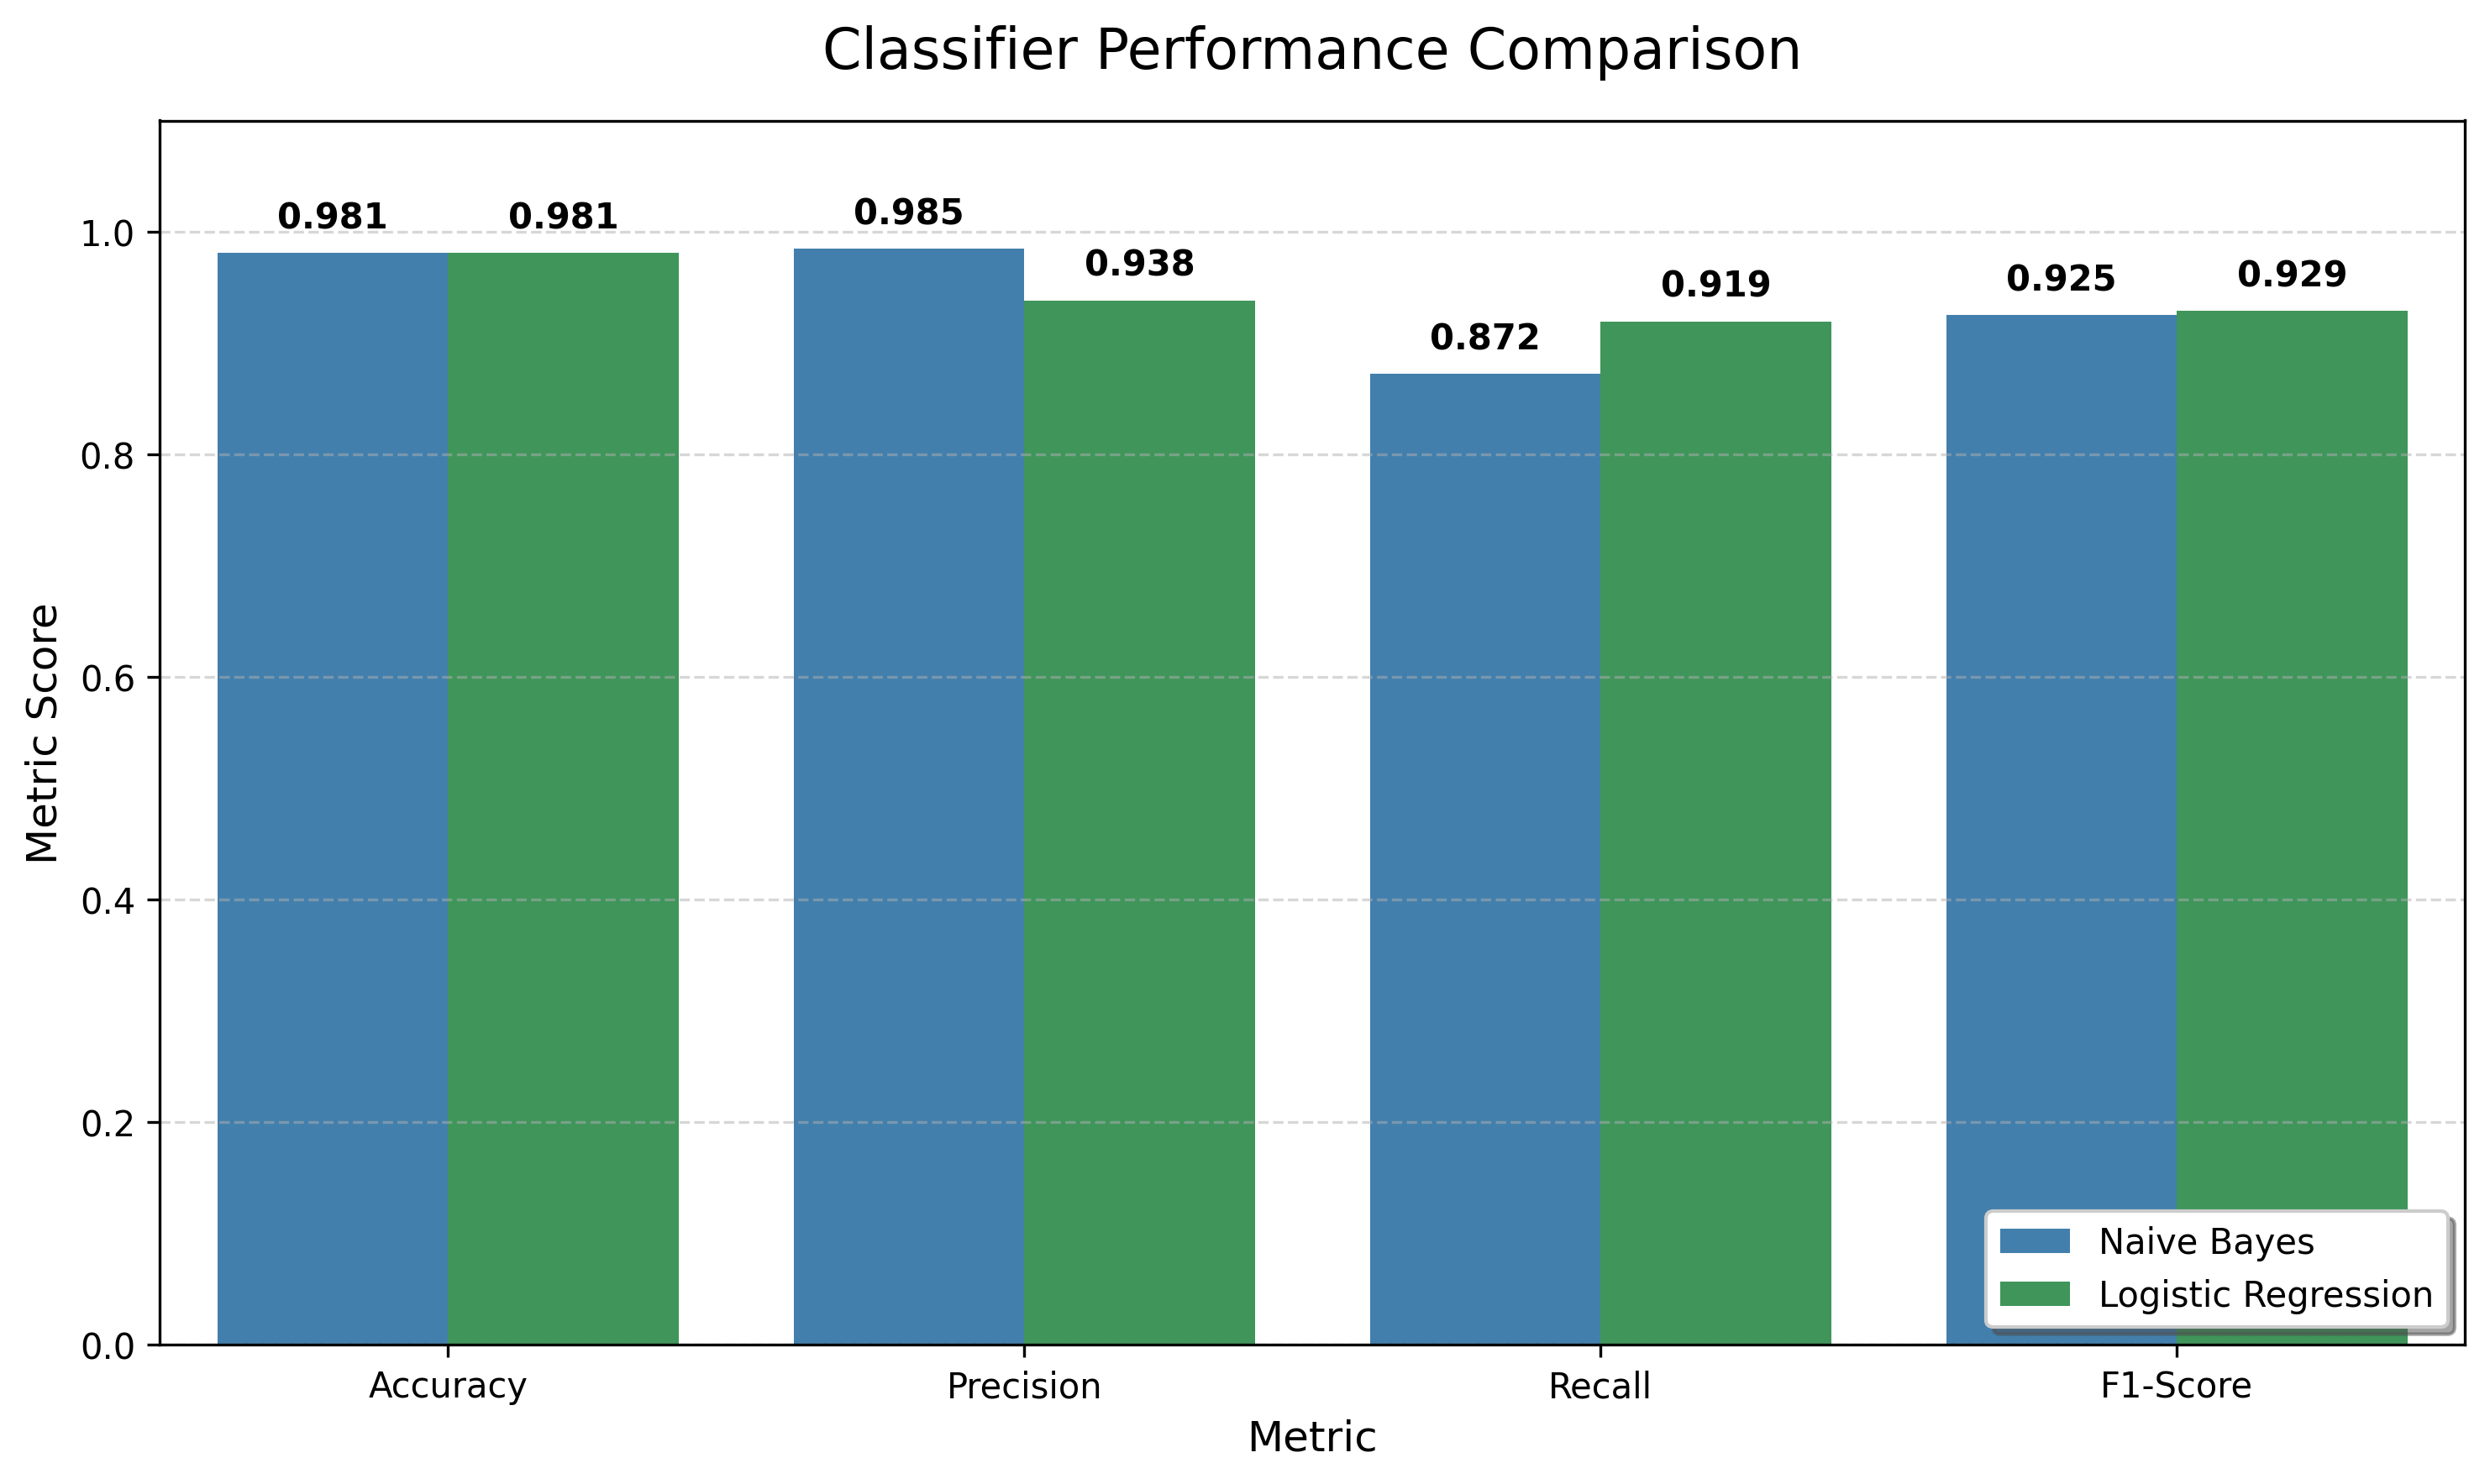

In [4]:
from PIL import Image

print("Confusion Matrix:")
display(Image.open('../plots/confusion_matrix.png'))

print("\nPerformance Comparison:")
display(Image.open('../plots/precision_recall_comparison.png'))

## 4. Key Concept Explanations

### 4.1 Why F1-Score matters more than Accuracy
Our dataset is highly imbalanced (~87% Ham, 13% Spam). If we build a dumb classifier that always predicts "Ham", we would achieve **87% Accuracy**, but it would catch **0% of Spam messages** (0% Recall).
Therefore, we use:
- **Precision**: Out of all flagged spam, how many are actually spam? (Minimizes false positives like flagging a job email as spam).
- **Recall**: Out of all actual spam, how many did we catch? (Minimizes false negatives).
- **F1-Score**: The harmonic mean of Precision and Recall. This serves as our primary model selection metric.

### 4.2 Parametric vs Non-Parametric Models
- **Logistic Regression** is a **parametric model** because it assumes a parametric structure (linear relationship between logits and features) and learns a fixed number of coefficients ($w_1, w_2, ...$).
- **K-Nearest Neighbors (KNN)** is **non-parametric** because it doesn't assume a functional form and grows in complexity with dataset size, making it slower at inference time for high-dimensional text data.

### 4.3 Bias-Variance Tradeoff
- **Naive Bayes** has high bias due to the "strong independence assumption" (assuming words are conditionally independent given the class). However, this simple structure makes it robust to overfitting (low variance), working extremely well even with smaller training data.
- **Logistic Regression** has lower bias and can model linear combinations of word weights. Overfitting (high variance) is controlled using L2 regularization.

## 5. Save the selected best performing model

In [5]:
save_path = os.path.join("..", "models", "model.pkl")
save_pipeline(vectorizer, best_model, best_model_name, best_metrics, save_path)

Saved best model artifacts to: ..\models\model.pkl
